## Total Fuel Evaluation (Sum of Phase Models)

In this section, we evaluate total fuel consumption by combining the phase-level ML predictions.

Steps:
1. Load the November–December test flights from the feature table and obtain the ground-truth total fuel (`total_fuel_modeled`).  
   If a total column is not available, we compute it by summing the phase fuel columns.
2. Load phase prediction files (takeoff, climb, cruise, descent, landing) exported earlier as CSV.
3. Merge predictions by `flight_id` and set missing phase predictions to 0 (phase not present or not predicted).
4. Compute total predicted fuel as the sum of predicted phase fuels.
5. Merge predictions with ground truth and report overall error metrics (MAE and MAPE).
6. Print average predicted fuel per phase and inspect the largest absolute errors for debugging.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DB_PATH = "../opensky.sqlite"
FEATURE_TABLE = "flight_phase_features"
YEAR = 2022

def add_datetime_from_flight_id(df: pd.DataFrame, year: int) -> pd.DataFrame:
    parts = df["flight_id"].astype(str).str.split("-", expand=True)
    month  = parts[2].astype(int)
    day    = parts[3].astype(int)
    hour   = parts[4].astype(int)
    minute = parts[5].astype(int)
    out = df.copy()
    out["flight_dt"] = pd.to_datetime(
        {"year": year, "month": month, "day": day, "hour": hour, "minute": minute},
        errors="coerce"
    )
    return out

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return 100*np.mean(np.abs((y_true - y_pred)/np.clip(np.abs(y_true),1e-6,None)))

# --- load test truth ---
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f'SELECT * FROM "{FEATURE_TABLE}"', conn)
conn.close()

df = add_datetime_from_flight_id(df, YEAR)
df = df[df["flight_dt"].notna()].copy()
df["month"] = df["flight_dt"].dt.month
test = df[df["month"].isin([11,12])].copy()

true_total_col = "total_fuel_modeled"
if true_total_col not in test.columns:
    phase_cols = ["takeoff_fuel","climb_fuel","cruise_fuel","descent_fuel","landing_fuel"]
    test["true_total"] = test[phase_cols].sum(axis=1)
    true_total_col = "true_total"

truth = test[["flight_id", true_total_col]].rename(columns={true_total_col:"true_total"})

csv_dir = ("csv_files")
for fname in (
    "pred_takeoff.csv",
    "pred_climb.csv",
    "pred_cruise.csv",
    "pred_descent.csv",
    "pred_landing.csv",
):
    full = os.path.join(csv_dir, fname)
    if not os.path.exists(full):
        raise FileNotFoundError(f"prediction file not found: {full}")

p_takeoff = pd.read_csv(os.path.join(csv_dir, "pred_takeoff.csv"))
p_climb   = pd.read_csv(os.path.join(csv_dir, "pred_climb.csv"))
p_cruise  = pd.read_csv(os.path.join(csv_dir, "pred_cruise.csv"))
p_descent = pd.read_csv(os.path.join(csv_dir, "pred_descent.csv"))
p_landing = pd.read_csv(os.path.join(csv_dir, "pred_landing.csv"))

pred_all = (p_takeoff
    .merge(p_climb, on="flight_id", how="outer")
    .merge(p_cruise, on="flight_id", how="outer")
    .merge(p_descent, on="flight_id", how="outer")
    .merge(p_landing, on="flight_id", how="outer")
)

for c in ["pred_takeoff","pred_climb","pred_cruise","pred_descent","pred_landing"]:
    pred_all[c] = pred_all[c].fillna(0.0)

pred_all["pred_total"] = pred_all[["pred_takeoff","pred_climb","pred_cruise","pred_descent","pred_landing"]].sum(axis=1)

# merge truth
pred_all = pred_all.merge(truth, on="flight_id", how="left")

mask = pred_all["true_total"].notna() & np.isfinite(pred_all["true_total"])
y_true = pred_all.loc[mask, "true_total"].to_numpy(float)
y_pred = pred_all.loc[mask, "pred_total"].to_numpy(float)

print("TOTAL RESULTS (sum of phase ML)")
print("N:", int(mask.sum()))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("MAPE:", mape(y_true, y_pred))
print(f"MSE : {mean_squared_error(y_true, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"R²  : {r2_score(y_true, y_pred):.4f}")



print(pred_all[[
    "pred_takeoff",
    "pred_climb",
    "pred_cruise",
    "pred_descent",
    "pred_landing"
]].mean())

pred_all["abs_err"] = abs(pred_all["true_total"] - pred_all["pred_total"])
pred_all.sort_values("abs_err", ascending=False).head(10)

TOTAL RESULTS (sum of phase ML)
N: 3506
MAE: 75.50487026567612
MAPE: 4.44889562285355
MSE : 12166.0866
RMSE: 110.3000
R²  : 0.9548
pred_takeoff      47.671283
pred_climb      1083.132186
pred_cruise      261.974691
pred_descent     324.949698
pred_landing       7.951302
dtype: float64


,flight_id,pred_takeoff,pred_climb,pred_cruise,pred_descent,pred_landing,pred_total,true_total,abs_err
201,478742-NOZ56U-12-15-20-11,59.567154,1464.73570,1148.732253,374.10382,10.483417,3057.622344,5794.31,2736.687656
2073,479ee7-NOZ50A-12-29-17-57,0.000000,1638.27890,1031.478995,308.43927,11.528344,2989.725509,4099.73,1110.004491
1235,479227-NOZ602-12-13-08-23,56.295513,1083.75460,778.322862,478.97757,8.207549,2405.558094,3223.76,818.201906
210,478742-NOZ628-12-21-17-45,52.974880,1141.60420,68.585301,333.59510,7.779460,1604.538942,2224.98,620.441058
1515,4792db-NOZ145-12-01-16-01,53.944862,446.83932,0.000000,261.88000,9.336014,772.000196,1273.72,501.719804
2273,47a05e-NOZ607-12-20-07-09,56.673530,1037.99410,207.565459,921.88086,8.280184,2232.394133,1780.62,451.774133
2007,479d40-NOZ145-12-22-16-36,52.761710,1342.95750,0.000000,311.48706,8.812188,1716.018458,2153.44,437.421542
2708,47a218-NOZ56U-12-04-20-01,63.593765,1490.72070,1042.388553,626.47170,9.899236,3233.073954,3659.06,425.986046
2338,47a097-NOZ541-12-29-16-04,0.000000,1212.11720,384.617924,627.74460,8.243013,2232.722737,2649.24,416.517263
2618,47a1ef-NOZ606-12-13-11-10,57.845657,1146.19310,262.029328,826.60790,7.974340,2300.650325,1885.38,415.270325


# Plot estimated vs actual total fuel

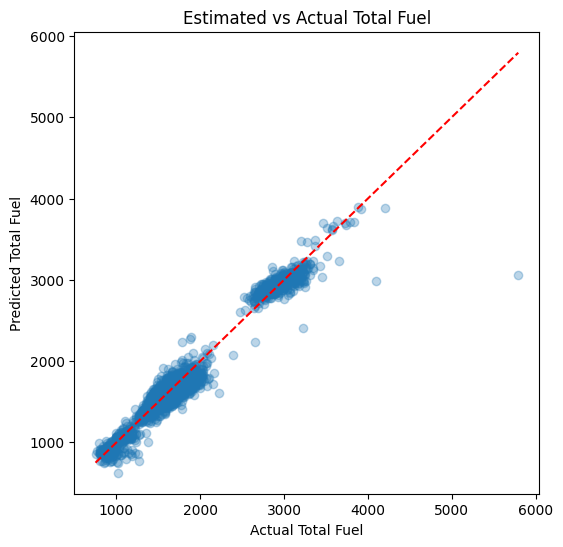

                      flight_id
201   478742-NOZ56U-12-15-20-11
2073  479ee7-NOZ50A-12-29-17-57
1235  479227-NOZ602-12-13-08-23
210   478742-NOZ628-12-21-17-45
1515  4792db-NOZ145-12-01-16-01
2273  47a05e-NOZ607-12-20-07-09
2007  479d40-NOZ145-12-22-16-36
2708  47a218-NOZ56U-12-04-20-01
2338  47a097-NOZ541-12-29-16-04
2618  47a1ef-NOZ606-12-13-11-10
1311  4792a6-NOZ347-12-30-17-50
294   47875c-NOZ143-12-18-15-15
2838  47a31a-NOZ133-11-22-14-52
1317  4792a6-NOZ522-12-08-06-12
2282  47a05e-NOZ631-12-16-15-46
899   4787b3-NOZ648-11-27-21-37
292   47875c-NOZ141-12-19-08-20
2363  47a0bf-NOZ133-12-02-14-57
3467  4aca46-NOZ549-12-01-16-57
2408  47a0bf-NOZ536-11-18-14-32


In [2]:

plt.figure(figsize=(6,6))
plt.scatter(
    pred_all["true_total"],
    pred_all["pred_total"],
    alpha=0.3
)

min_val = pred_all["true_total"].min()
max_val = pred_all["true_total"].max()

plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.xlabel("Actual Total Fuel")
plt.ylabel("Predicted Total Fuel")
plt.title("Estimated vs Actual Total Fuel")
plt.show()


pred_all["abs_err"] = abs(pred_all["true_total"] - pred_all["pred_total"])
pred_all.sort_values("abs_err", ascending=False).head(10)


pred_all["rel_err_pct"] = 100 * (
    (pred_all["pred_total"] - pred_all["true_total"])
    / pred_all["true_total"]
)

#print(pred_all["rel_err_pct"].describe())


outliers = pred_all.sort_values("abs_err", ascending=False).head(20)

cols = [
    "flight_id",
]

print(outliers[cols])

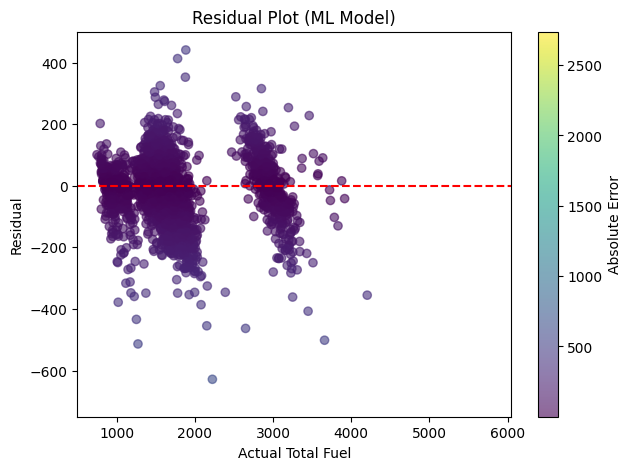

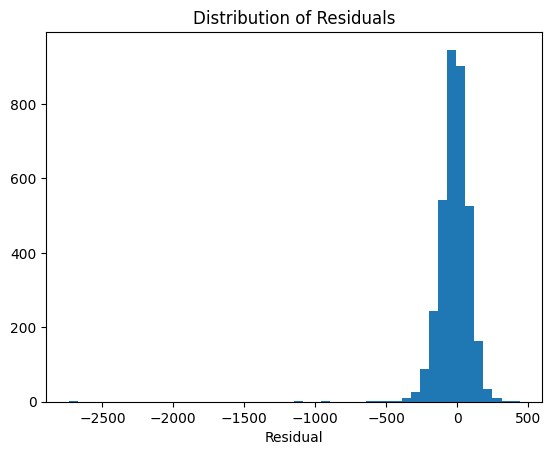

In [32]:
# compute residual (prediction - truth) if not already computed
if "residual" not in pred_all.columns:
    pred_all["residual"] = pred_all["pred_total"] - pred_all["true_total"]

plt.figure(figsize=(7,5))

plt.ylim(-750, 500)

plt.scatter(
    pred_all["true_total"],
    pred_all["residual"],
    c=pred_all["abs_err"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Absolute Error")
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Actual Total Fuel")
plt.ylabel("Residual")
plt.title("Residual Plot (ML Model)")

plt.show()

plt.hist(pred_all["residual"], bins=50)
plt.xlabel("Residual")
plt.title("Distribution of Residuals")
plt.show()

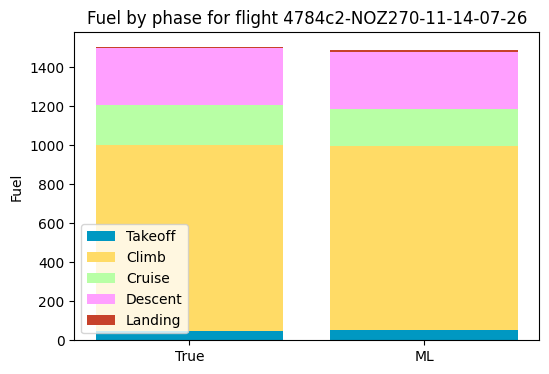

In [33]:
phases_true = [
    "takeoff_fuel",
    "climb_fuel",
    "cruise_fuel",
    "descent_fuel",
    "landing_fuel"
]

phases_pred = [
    "pred_takeoff",
    "pred_climb",
    "pred_cruise",
    "pred_descent",
    "pred_landing"
]

colors = {
    "takeoff_fuel": "#0098c2",
    "climb_fuel": "#ffdb66",
    "cruise_fuel": "#b8ffa5",
    "descent_fuel": "#ff9fff",
    "landing_fuel": "#c7422b"
}


phase_truth = test[[
    "flight_id",
    "takeoff_fuel",
    "climb_fuel",
    "cruise_fuel",
    "descent_fuel",
    "landing_fuel"
]].drop_duplicates("flight_id")

pred_all = pred_all.merge(phase_truth, on="flight_id", how="left")

row = pred_all.iloc[3]

fig, ax = plt.subplots(figsize=(6,4))

bottom_true = 0
bottom_pred = 0

for true_col, pred_col in zip(phases_true, phases_pred):

    ax.bar(
        "True",
        row[true_col],
        bottom=bottom_true,
        color=colors[true_col],
        label=true_col.replace("_fuel","").capitalize()
    )

    ax.bar(
        "ML",
        row[pred_col],
        bottom=bottom_pred,
        color=colors[true_col]
    )

    bottom_true += row[true_col]
    bottom_pred += row[pred_col]

ax.set_ylabel("Fuel")
ax.set_title(f"Fuel by phase for flight {row['flight_id']}")

ax.legend()

plt.show()

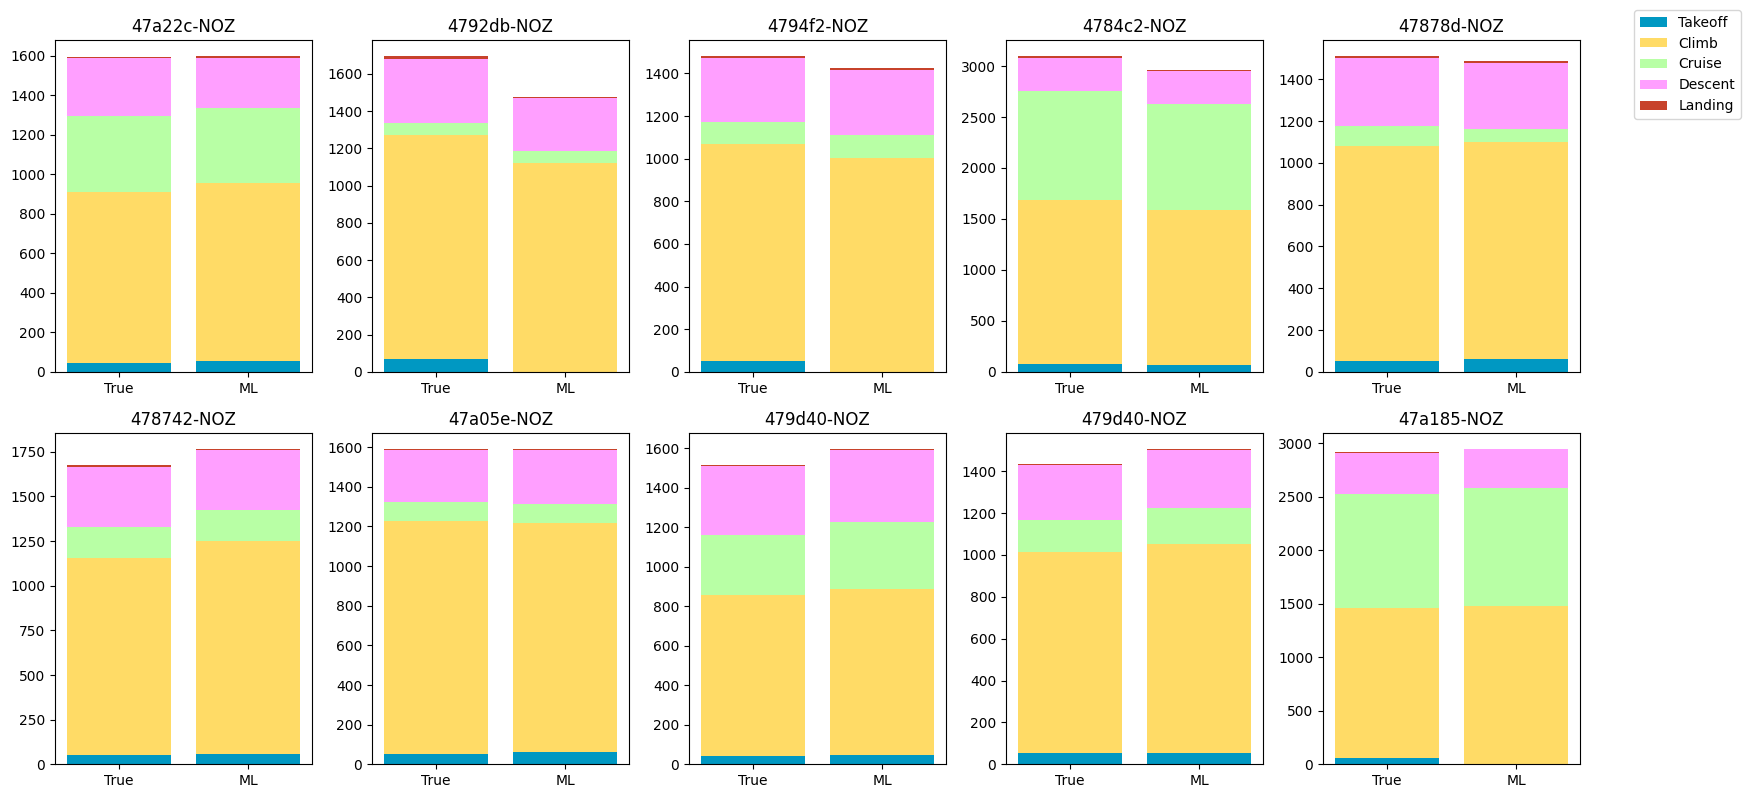

In [34]:
n = 10
sample = pred_all.sample(n, random_state=2)

cols = 5
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16,4*rows))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample.iterrows()):

    bottom_true = 0
    bottom_pred = 0

    for true_col, pred_col in zip(phases_true, phases_pred):

        label = true_col.replace("_fuel","").capitalize()

        ax.bar(
            "True",
            row[true_col],
            bottom=bottom_true,
            color=colors[true_col],
            label=label
        )

        ax.bar(
            "ML",
            row[pred_col],
            bottom=bottom_pred,
            color=colors[true_col]
        )

        bottom_true += row[true_col]
        bottom_pred += row[pred_col]

    ax.set_title(row["flight_id"][:10])
    ax.set_xticks([0,1])
    ax.set_xticklabels(["True","ML"])

# fjern tomme plots
for ax in axes[n:]:
    ax.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()